In [1]:
import numpy as np
import BLEanalysis.angleinference as AngleInference
np.set_printoptions(precision=2,suppress=True)
import matplotlib.pyplot as plt
from BLEanalysis.signals import Signals
import pyproj
from BLEanalysis.angleinference import AnglesUsePeaks, AnglesUsePatternMeans, normalise_logs_to_ps
from BLEanalysis.pathinference import Path_ProbabilityDensitiesToBee, Path_VectorsToBee
from BLEanalysis.kernels import ExponentiatedQuadraticKernel
from matplotlib.pyplot import figure
from BLEanalysis import confidence_ellipse

Normalizing the transmitter positions (TODO: Do this in a method in angleinference object):

Text(-33.024321146076545, -19.46815541945398, 'Copse of Trees')

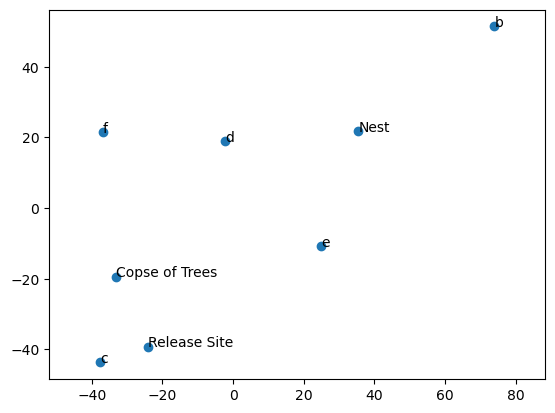

In [3]:
# coords for transmitters b,c,d,e,f, release site, nest, copse of trees
lon = [-1.539777,-1.541483,-1.540932,-1.540533,-1.541451,-1.541279, -1.540364,-1.541405] # x axis
lat = [53.356765,53.355931,53.356487,53.356215,53.356516, 53.355968, 53.356505, 53.356148] # y axis
P = pyproj.Proj(proj='utm', zone=30, ellps='WGS84', preserve_units=True)
xxLon, yyLat = P(lon,lat)

def normaliseXY(coordsX, coordsY):
    Xavg = np.sum(coordsX)/len(coordsX)
    Yavg = np.sum(coordsY)/len(coordsY)
    for coord in range(len(coordsX)):
        coordsX[coord] = (coordsX[coord] - Xavg)
    for coord in range(len(coordsY)):
        coordsY[coord] = (coordsY[coord] - Yavg)
    return coordsX, coordsY, Xavg, Yavg

def reverseNormalizeXY(coordsX, coordsY, Xavg, Yavg):
    for coord in range(len(coordsX)):
        coordsX[coord] = coordsX[coord] + Xavg
    for coord in range(len(coordsY)):
        coordsY[coord] = coordsY[coord] + Yavg
    return coordsX, coordsY
    
xx,yy,Xaverage,Yaverage = normaliseXY(xxLon,yyLat)

plt.axis("equal")
plt.scatter(xx,yy)
plt.text(xx[0],yy[0],'b')
plt.text(xx[1],yy[1],'c')
plt.text(xx[2],yy[2],'d')
plt.text(xx[3],yy[3],'e')
plt.text(xx[4],yy[4],'f')
plt.text(xx[5],yy[5],'Release Site')
plt.text(xx[6],yy[6],'Nest')
plt.text(xx[7],yy[7],'Copse of Trees')

Load data, add transmitter locations and shift times:

Packets used to calibrate time: (take a zero point, minus real time difference between time that zero point was taken and packet, use that time difference to move packet time to zero point time, subtract to get offset)

[2025-08-19 12:21:40.244] RSSI: -95 [da:2a:91:2a:11:8c] 2789674 + 112679 = 2902353. 2468288 - 2902353 = - 434065

[2025-08-19 12:21:40.531] RSSI: -97 [da:25:6e:fd:07:7e] 2453245 + 112392 = 2565637. 2468288 - 2565637 = -97349

[2025-08-19 12:23:32.923] RSSI: -96 [da:25:a9:c0:07:2b] 2468288 (zero point)

[2025-08-19 12:23:33.038] RSSI: -94 [da:29:69:82:00:7d] 2713986 - 1060 = 2712926. 2468288 - 2712926 = -244638

[2025-08-19 12:22:35.435] RSSI: -96 [da:29:f8:4f:0e:7f] 2750543 + 57488 = 2808031. 2468288 - 2808031 = -339743



In [5]:
testdata = Signals("../../tagtest2.txt",['b','e','f'],filetype='pcap',angleOffset=0)

Standardising angles and times (shifting by 0.00 degrees)


In [6]:
testdata.summarise()
testdata.configureTransmitter('b',0,0,transmitterLat = yy[0], transmitterLon = xx[0])
testdata.configureTransmitter('c',434065,0,transmitterLat = yy[1], transmitterLon = xx[1])
testdata.configureTransmitter('d',244638,0,transmitterLat = yy[2], transmitterLon = xx[2])
testdata.configureTransmitter('e',97349,0,transmitterLat = yy[3], transmitterLon = xx[3])
testdata.configureTransmitter('f',339743,0,transmitterLat = yy[4], transmitterLon = xx[4])

Transmitter       Number of records
        b                   34
        e                   74
        f                   66


Use peaks to get angle (just as a quick method, do something more robust later - the data is super noisy D:)

In [47]:
burst, time = testdata.parseBursts(burstInterval=2000)
angles = AnglesUsePeaks(3)

In [51]:
for i in range(len(burst)):
    prediction = angles.infer(burst[i]['rssis'], burst[i]['angles'])
    if not np.isnan(prediction):
        observation = np.array([burst[i]['transmitter_position'][0][0],burst[i]['transmitter_position'][0][1],np.cos(prediction),np.sin(prediction)])
        obstimes.append(time[i])
        obs.append(observation)

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [53]:
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / 10000

Text(-33.024321146076545, -19.46815541945398, 'Copse of Trees')

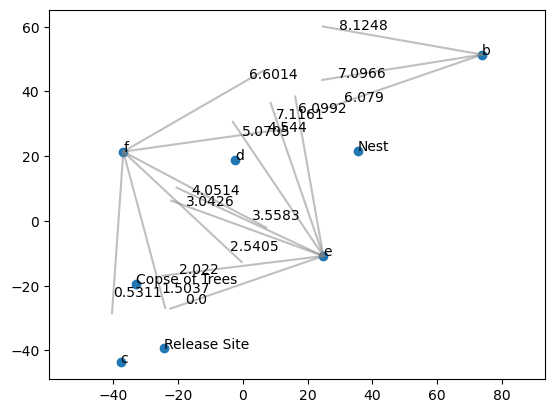

In [57]:
plt.axis('equal')
plt.scatter(xx,yy)
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[1], observation[1]+observation[3]*50],[observation[0],observation[0]+observation[2]*50],color='grey',alpha=0.5)
    plt.text(observation[1]+observation[3]*45, observation[0]+observation[2]*45, time)

plt.text(xx[0],yy[0],'b')
plt.text(xx[1],yy[1],'c')
plt.text(xx[2],yy[2],'d')
plt.text(xx[3],yy[3],'e')
plt.text(xx[4],yy[4],'f')
plt.text(xx[5],yy[5],'Release Site')
plt.text(xx[6],yy[6],'Nest')
plt.text(xx[7],yy[7],'Copse of Trees')

In [59]:
#obstimes = [6,7,8,0,2,3,4,5,6,7,0,2,3,4,5,7] # Just using burst number right now, technically on holiday so haven't done the time conversion yet :)
from BLEanalysis.pathinference import Path_VectorsToBee
k = ExponentiatedQuadraticKernel(6,100.0)
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,10,0.5)
path.run(500,learning_rate=0.3)

Optimising mean...
iteration    0:  125477.9
iteration   50:  109366.9
iteration  100:  102566.8
iteration  150:   99451.2
iteration  200:   97980.4
iteration  250:   97312.3
iteration  300:   97022.6
iteration  350:   96898.1
iteration  400:   96842.2
iteration  450:   96815.4
Optimising mean and covariance...
iteration    0:   34789.8
iteration   50:    2903.0
iteration  100:    2571.5
iteration  150:    2427.7
iteration  200:    2351.2
iteration  250:    2305.1
iteration  300:    2276.9
iteration  350:    2259.4
iteration  400:    2247.9
iteration  450:    2239.7


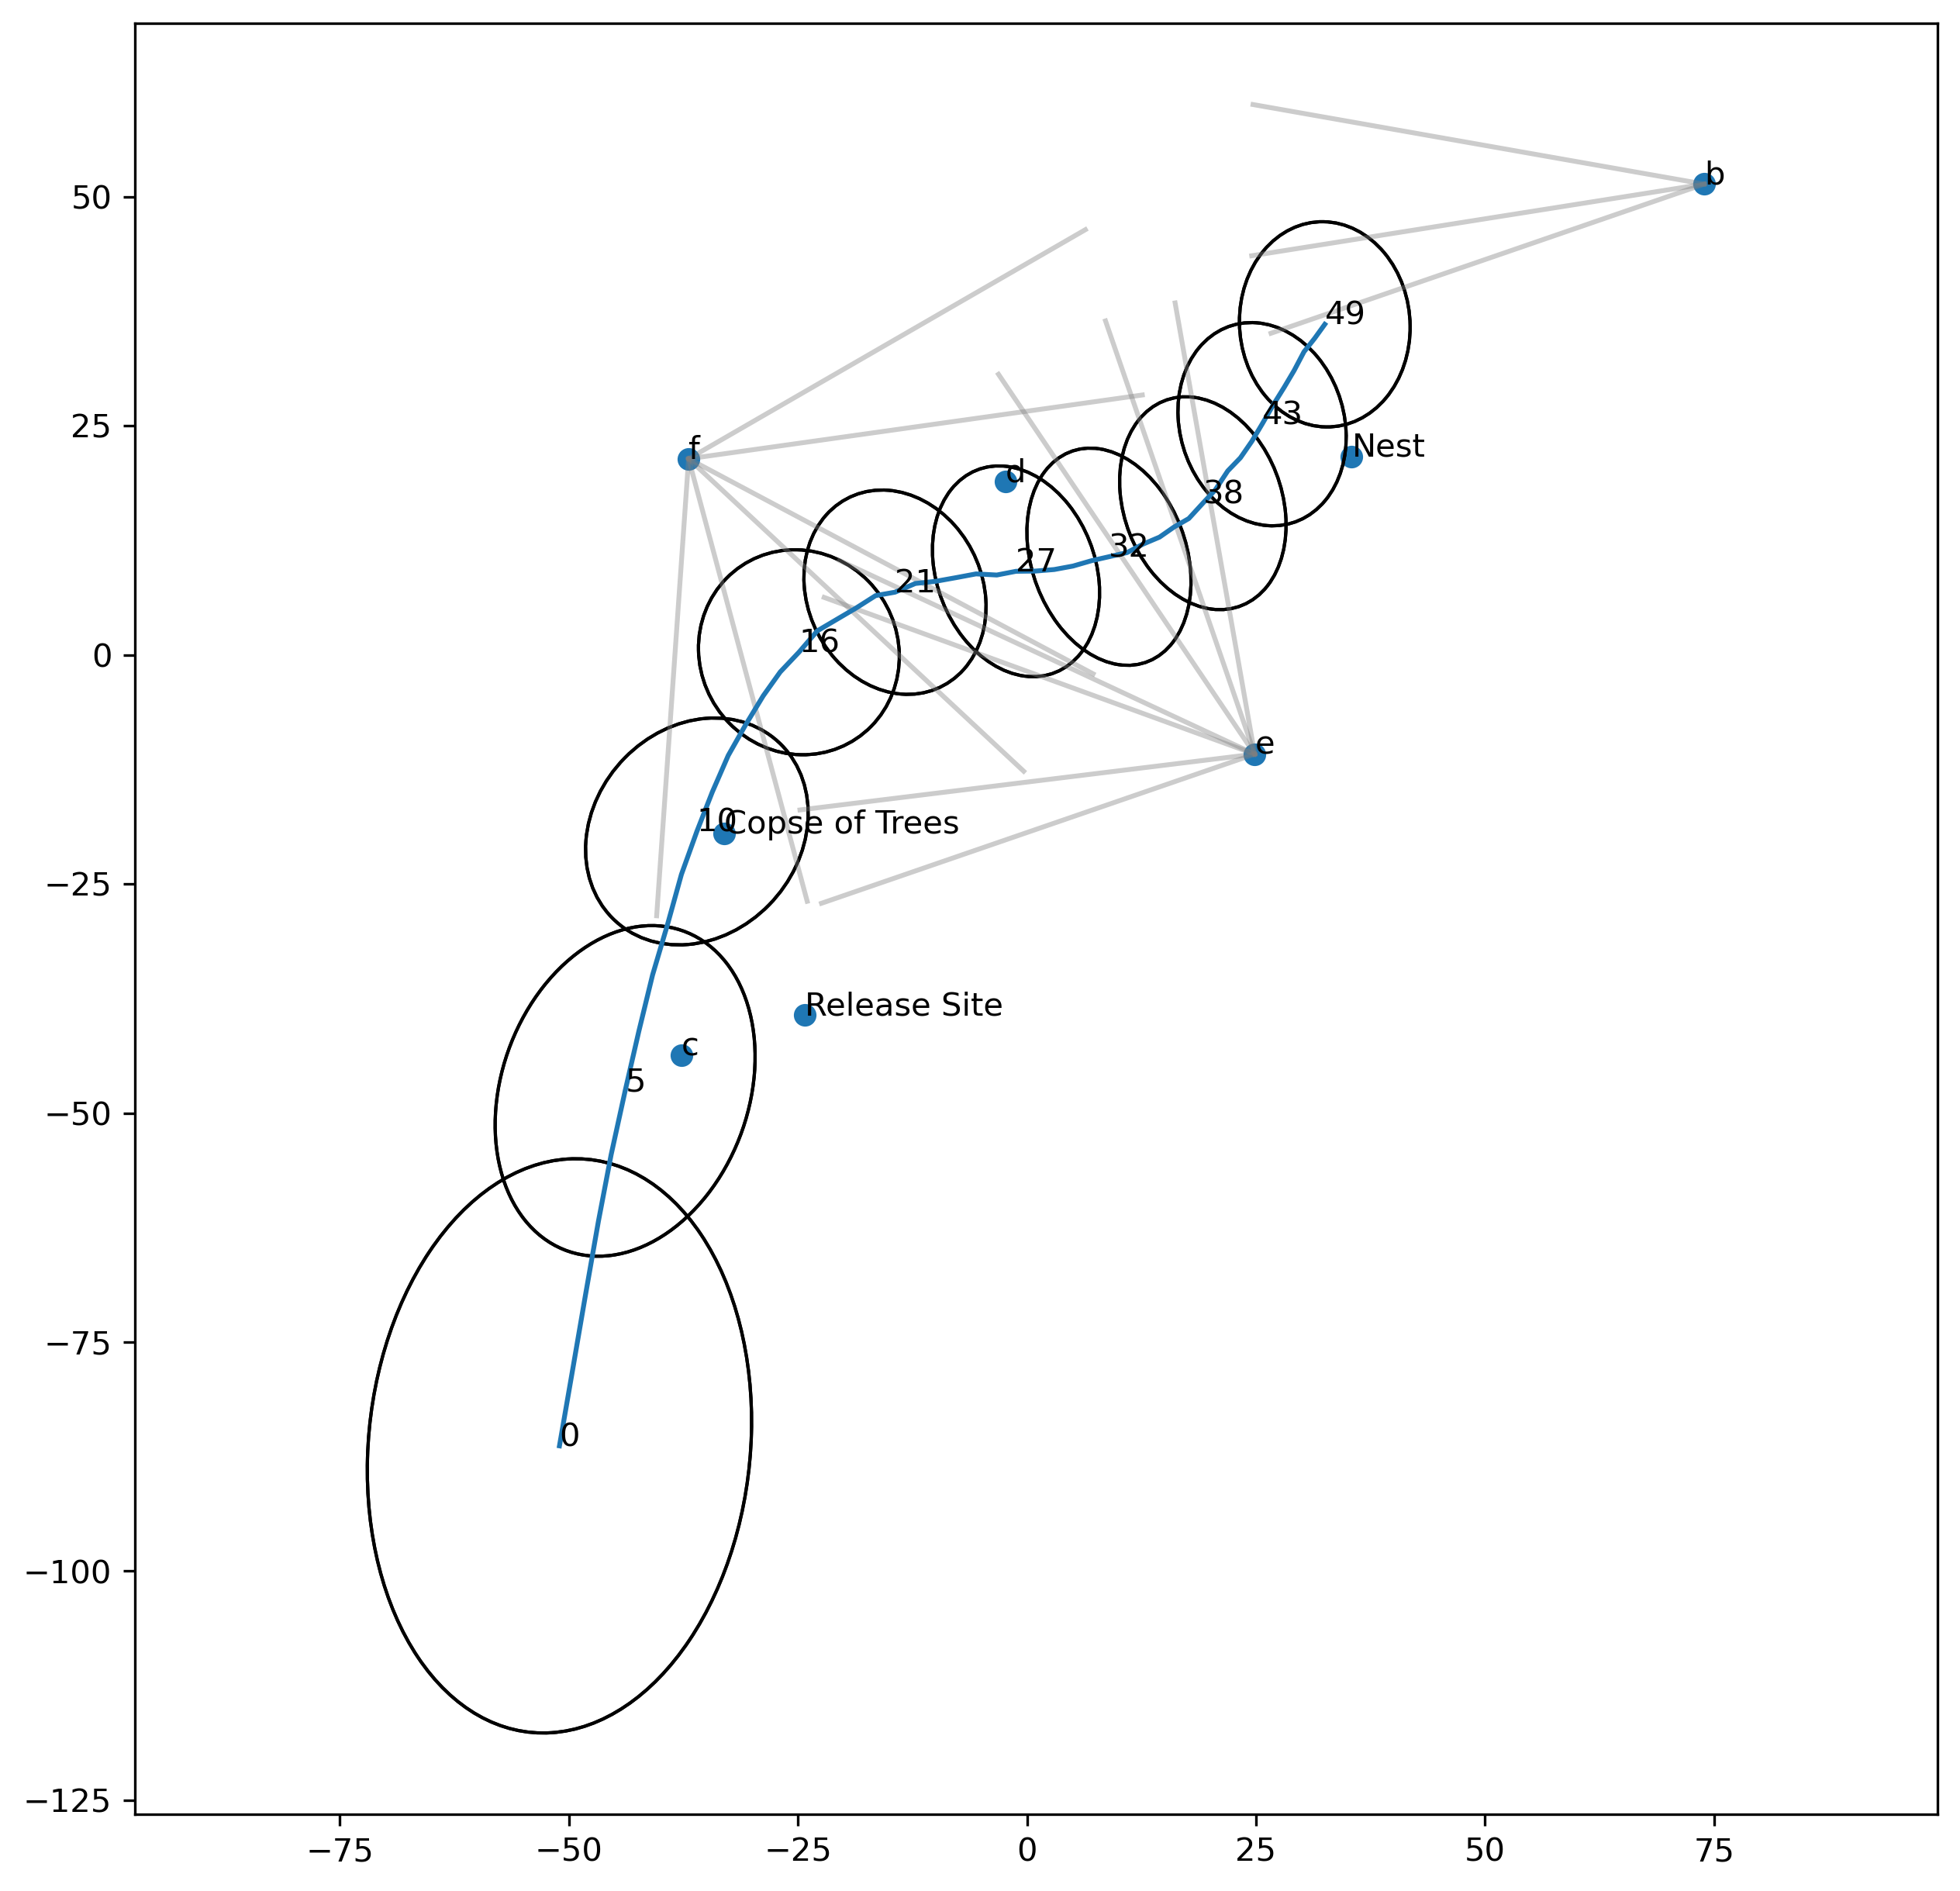

In [61]:
figure(figsize=(10, 10), dpi=300)
plt.axis("equal")
plt.scatter(xx,yy)
plt.text(xx[0],yy[0],'b')
plt.text(xx[1],yy[1],'c')
plt.text(xx[2],yy[2],'d')
plt.text(xx[3],yy[3],'e')
plt.text(xx[4],yy[4],'f')
plt.text(xx[5],yy[5],'Release Site')
plt.text(xx[6],yy[6],'Nest')
plt.text(xx[7],yy[7],'Copse of Trees')

for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[1], observation[1]+observation[3]*50],[observation[0],observation[0]+observation[2]*50],color='grey',alpha=0.4)
n_test = 50
posterior_mean, posterior_cov = path.get_predictions(np.linspace(-0.1,6,n_test))
plt.plot(posterior_mean[:n_test] + -0.7,posterior_mean[n_test:]+25.5,'-')
ax = plt.gca()
for i in np.linspace(0,n_test-1,10).astype(int):
    el = confidence_ellipse(posterior_mean[i::n_test] + np.array([-0.7,25.5]),posterior_cov[i::n_test,i::n_test],ax,n_std=2)
    ax.add_patch(el)
    plt.text(posterior_mean[i::n_test][0] - 0.7,posterior_mean[i::n_test][1] +25.5,int(i))
#posterior_mean[0::n_test],posterior_cov[0::n_test,0::n_test]
plt.savefig('demo.png', transparent=True)